# Experiments for $\operatorname{BE}(\alpha)$

## Imports and setup

In [1]:
from abc import ABC, abstractmethod
import random
import numpy as np
import matplotlib.pyplot as plt
import math

## Agents

In [2]:
from abc import ABC, abstractmethod

class Agent(ABC):
    def __init__(self, K):
        """Initialize the agent for a K-armed bandit."""
        self.K = K

    @abstractmethod
    def pull(self):
        """Return the next arm to pull (an integer between 1 and K inclusive)."""
        pass

    @abstractmethod
    def observe(self, reward):
        """Receive the observed reward (a scalar)."""
        pass

### Random agent

In [3]:
class RandomAgent(Agent):
    def __init__(self, K, seed=None):
        """Initialize the random agent with an optional seed for deterministic behavior."""
        super().__init__(K)
        self.seed = seed
        if self.seed is not None:
            random.seed(self.seed)

    def pull(self):
        """Randomly select an arm between 1 and K inclusive."""
        return random.randint(1, self.K)

    def observe(self, reward):
        """Random agent does not learn from feedback."""
        pass

### Windowed agent

In [4]:
class WindowedAgent(Agent):
    def __init__(self, K):
        super().__init__(K)
        self.w = 1
        self.d = 1

    @abstractmethod
    def _get_window_length(self):
        pass

    @abstractmethod
    def _reset_window(self):
        pass

    def _update_window(self):
        self.d += 1
        if self.d == self._get_window_length():
            self.w += 1
            self.d = 1
            self._reset_window()

#### $\operatorname{BE}(\alpha)$

In [5]:
class BEAlphaAgent(WindowedAgent):
    def __init__(self, K, alpha, sigma):
        super().__init__(K)
        self.alpha = alpha
        self.sigma = sigma
        self._reset_window()

    def pull(self):
        self.last_pulled = min(self.B) + 1
        return self.last_pulled

    def observe(self, reward):
        self.S[self.last_pulled - 1] += reward
        self.B.remove(self.last_pulled - 1)

        if not self.B:
            self._eliminate_arms(max([self.S[i] for i in self.A]))

        super()._update_window()

    def _get_window_length(self):
        return math.ceil(self.w ** self.alpha)

    def _eliminate_arms(self, max_reward):
        delta_w = self._get_window_length()
        B_w = 2 * (1 + 2 * self.sigma * math.sqrt(delta_w * math.log(2 * self.K * delta_w)))
        self.B = {i for i in self.A if self.S[i] + B_w >= max_reward}

    def _reset_window(self):
        self.S = [0.0] * self.K
        self.A = set(range(self.K))
        self.B = self.A.copy()

#### Rexp3

In [6]:
class Rexp3Agent(WindowedAgent):
    def __init__(self, K, delta, gamma):
        super().__init__(K)
        self.delta = delta
        self.gamma = gamma
        self._reset_window()

    def pull(self):
        self.last_pulled = np.random.choice(np.arange(1, self.K + 1), p=self.p)
        return self.last_pulled

    def observe(self, reward):
        self.weights[self.last_pulled - 1] *= np.exp(self.gamma / self.K * reward / self.p[self.last_pulled - 1])
        self._update_p()
        super()._update_window()

    def _get_window_length(self):
        return self.delta

    def _reset_window(self):
        self.weights = np.ones(self.K)
        self._update_p()

    def _update_p(self):
        self.p = (1 - self.gamma) * self.weights / np.sum(self.weights) + self.gamma / self.K

### R-less-UCB

In [7]:
class RLessUCBAgent(Agent):
    def __init__(self, K, epsilon, alpha, sigma, initial_capacity=2**10):
        super().__init__(K)
        self.epsilon = epsilon
        self.alpha = alpha
        self.sigma = sigma
        self.initial_capacity = initial_capacity

        self.rewards = np.full((self.K, self.initial_capacity), 0.)
        self.rewards_counts = np.zeros(self.K, dtype=int)
        self.preds = np.full(self.K, np.inf)
        self.ucbs = np.full(self.K, np.inf)
        self.t = 1

    def pull(self):
        self.last_pulled = np.argmax(self.ucbs) + 1
        return self.last_pulled

    def observe(self, reward):
        if self.rewards_counts[self.last_pulled - 1] >= self.rewards.shape[1]:
            self._expand_rewards()

        self.rewards[self.last_pulled - 1, self.rewards_counts[self.last_pulled - 1]] = reward
        self.rewards_counts[self.last_pulled - 1] += 1
        self.t += 1

        self._update_preds()
        self._update_ucbs()

    def _expand_rewards(self):
        new_capacity = self.rewards.shape[1] * 2
        new_rewards = np.full((self.K, new_capacity), 0.)
        new_rewards[:, :self.rewards.shape[1]] = self.rewards
        self.rewards = new_rewards

    def _update_preds(self):
        h = np.floor(self.epsilon * self.rewards_counts).astype(int)
        self.preds[:] = np.inf
        non_zero_h = (h > 0)

        n = self.rewards_counts[non_zero_h]
        h = h[non_zero_h]
        rewards = self.rewards[non_zero_h, :n]

        # Efficient calculation of pred_values for non-zero h
        rewards_slice = rewards_arm[:, n_arm - h_arm:n_arm]  # Get the last h rewards
        time_diffs = self.t - np.arange(n_arm - h_arm + 1, n_arm + 1)  # The time differences (t - l)
        reward_diffs = rewards_slice[:, 1:] - rewards_slice[:, :-1]  # The reward differences
        pred_values = rewards_slice[:, :-1] + time_diffs[:, 1:] * reward_diffs / h_arm[:, None]  # Broadcasting

        # Set the predictions for the arms with h > 0
        self.preds[non_zero_h] = np.mean(pred_values, axis=1)

    def _update_ucbs(self):
        """ Efficiently update the UCBs for each arm. """
        # Get the number of rewards for each arm
        n = self.rewards_counts

        # Calculate h for each arm (epsilon * n)
        h = np.floor(self.epsilon * n).astype(int)

        # Initialize ucbs array with np.inf for arms with h == 0
        self.ucbs[:] = np.inf  # Set all ucbs to inf initially
        non_zero_h = (h > 0)  # Get the arms where h > 0

        # For arms with h > 0, calculate the UCB using vectorized operations
        n_arm = n[non_zero_h]
        h_arm = h[non_zero_h]
        preds_arm = self.preds[non_zero_h]

        # Calculate delta
        delta = (self.t ** (-self.alpha))

        # Calculate the UCBs using vectorized operations
        t_diffs = self.t - n_arm + h_arm - 1  # (t - n + h - 1)
        ucb_values = preds_arm + self.sigma * t_diffs * np.sqrt(10 * np.log(1 / delta) / (h_arm**3))  # Broadcasting

        # Set the UCBs for the arms with h > 0
        self.ucbs[non_zero_h] = ucb_values

## Instances

In [8]:
class Instance(ABC):
    def __init__(self, K):
        """Initialize the instance for a K-armed bandit."""
        self.K = K

    @abstractmethod
    def next_payoffs(self):
        """
        Return a tuple of K elements representing the payoffs
        for each arm at the current round.
        """
        pass

### Random instance

In [9]:
class RandomInstance(Instance):
    def __init__(self, K, seed=None):
        """Initialize the random instance with K arms and an optional seed."""
        super().__init__(K)
        self.seed = seed
        if self.seed is not None:
            random.seed(self.seed)

    def next_payoffs(self):
        """Generate random payoffs between 0 and 1 for each arm."""
        return tuple(random.uniform(0, 1) for _ in range(self.K))

### Exponential instance

In [10]:
class ExponentialInstance:
    def __init__(self, K, seed=None):
        self.K = K
        self.t = 1

        if seed is not None:
            np.random.seed(seed)

        self.c = np.random.rand(K)
        self.a = np.random.rand(K)

    def next_payoffs(self):
        payoffs = self.c * (1 - np.exp(-self.a * self.t))
        self.t += 1
        return payoffs

## Runs

In [11]:
def run(K, T, agent, instance, sigma=1.0):
    """
    Run a bandit experiment.

    Parameters:
    - K: number of arms
    - T: time horizon
    - agent: an Agent instance
    - instance: an Instance instance
    - sigma: standard deviation of the noise added to the reward

    Returns:
    - regrets_per_round: list of cumulative regrets at each round
    """
    cumulative_regret = 0.0
    regrets_per_round = []

    for t in range(1, T + 1):
        # Get the payoffs for this round
        payoffs = instance.next_payoffs()  # tuple of K elements

        # Agent selects an arm (in [1, K])
        arm = agent.pull()
        arm_index = arm - 1  # adjust for Python 0-based indexing

        # Add some noise to the payoff
        noise = random.gauss(0, sigma)
        observed_reward = payoffs[arm_index] + noise

        # Give feedback to the agent
        agent.observe(observed_reward)

        # Compute regret
        best_payoff = max(payoffs)
        instant_regret = best_payoff - payoffs[arm_index]
        cumulative_regret += instant_regret

        # Store the cumulative regret at this round
        regrets_per_round.append(cumulative_regret)

    return regrets_per_round


In [12]:
def compare_agents(K, T, agents, instance, sigma, n_runs=10):
    avg_regrets = []
    std_regrets = []

    for agent in agents:
        # Run multiple times for the current agent
        regrets_per_run = []

        for _ in range(n_runs):
            cumulative_regret = run(K, T, agent, instance, sigma)
            regrets_per_run.append(cumulative_regret)

        # Calculate the average and standard deviation of cumulative regrets
        avg_regrets.append(np.mean(regrets_per_run, axis=0))
        std_regrets.append(np.std(regrets_per_run, axis=0))

    return avg_regrets, std_regrets

def plot_comparison(K, T, agents, instance, sigma):
    """
    Plots the comparison of multiple agents.

    Parameters:
    - K: Number of arms.
    - T: Learning horizon (number of time steps).
    - agents: List of agent instances to compare.
    - instance: Instance of the MAB problem.
    - sigma: Noise standard deviation for the environment.
    """
    avg_regrets, std_regrets = compare_agents(K, T, agents, instance, sigma)

    plt.figure(figsize=(10, 6))

    # Plot each agent's performance
    for i, agent in enumerate(agents):
        label = type(agent).__name__  # Using the agent class name as the label
        plt.plot(np.arange(T), avg_regrets[i], label=f"{label} (Avg)", linewidth=2)
        plt.fill_between(np.arange(T),
                         avg_regrets[i] - std_regrets[i],
                         avg_regrets[i] + std_regrets[i],
                         alpha=0.2)

    plt.xlabel("Time Step (t)")
    plt.ylabel("Cumulative Regret")
    plt.title("Comparison of Multiple Agents")
    plt.legend()
    plt.grid(True)
    plt.show()

### Sanity check

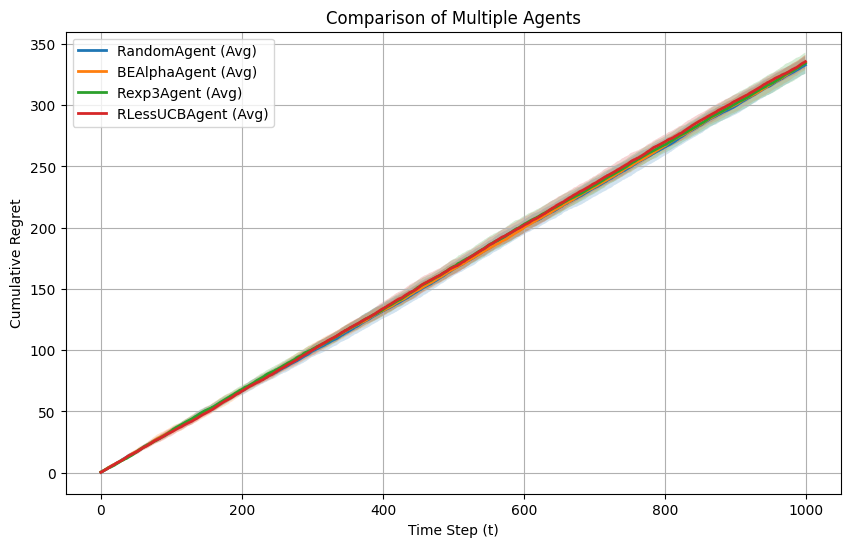

In [13]:
K = 5
T = 1000

random_agent = RandomAgent(K=K, seed=42)
bealpha_agent = BEAlphaAgent(K=K, alpha=0.5, sigma=0.1)
rexpr3_agent = Rexp3Agent(K=K, delta=100, gamma=0.1)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.1, alpha=3, sigma=0.1)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent]

instance = RandomInstance(K=K, seed=42)

plot_comparison(K=K, T=T, agents=agents, instance=instance, sigma=0.1)

### Experiment on the exponential instance

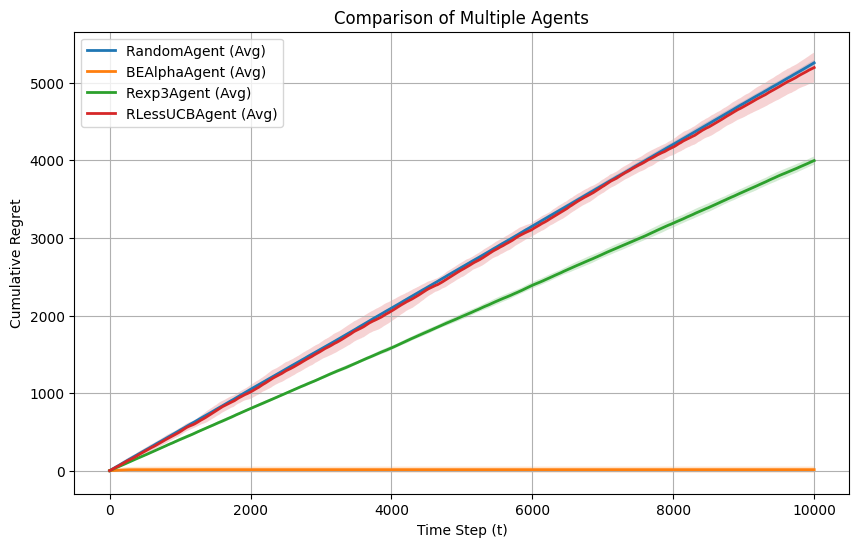

In [16]:
K = 50
T = 10000

random_agent = RandomAgent(K=K, seed=42)
bealpha_agent = BEAlphaAgent(K=K, alpha=8./3., sigma=0.1)
r_less_ucb_agent = RLessUCBAgent(K=K, epsilon=0.25, alpha=2.1, sigma=0.1)

rexpr3_delta = int(np.ceil((K * np.log(K)) ** (1./3.) * (T/(0.001*T)) ** (2./3.) ))
rexpr3_gamma = min([1., np.sqrt(K * np.log(K) / (math.e - 1.) / rexpr3_delta)])

rexpr3_agent = Rexp3Agent(K=K,
                          delta=rexpr3_delta,
                          gamma=rexpr3_gamma)

agents = [random_agent, bealpha_agent, rexpr3_agent, r_less_ucb_agent]

instance = ExponentialInstance(K=K, seed=42)

plot_comparison(K=K, T=T, agents=agents, instance=instance, sigma=0.1)